In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid") # Improve plot appearance
plt.rcParams["figure.figsize"] = (8,5)

import warnings
warnings.filterwarnings("ignore") # Ignore unnecessary warnings

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path("..")
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Telco_churn.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load dataset

df = pd.read_csv(DATA_PATH)

In [ ]:
# Quick verification

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 7043
Columns : 33


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [ ]:
missing = df.isnull().sum()

missing[missing>0]

,0
Churn Reason,5174


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


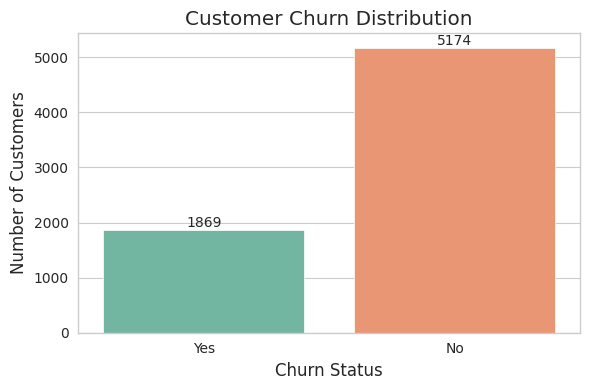

In [ ]:
# Customer Churn Distribution

plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Churn Label",
    palette="Set2"
)

# Add count labels on top of bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

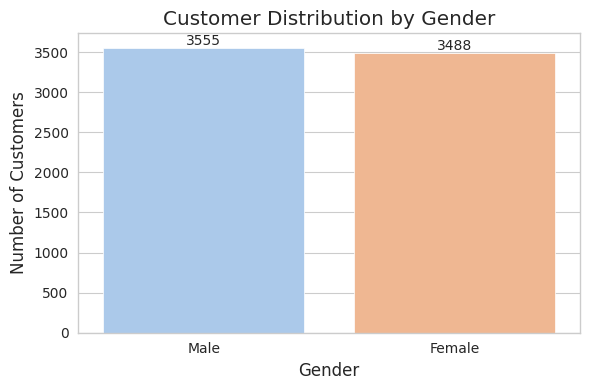

In [ ]:
# Customer Demographics Analysis
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Gender",
    palette="pastel"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

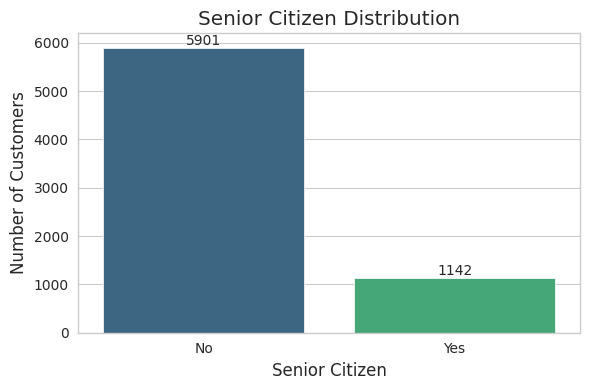

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Senior Citizen",
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Senior Citizen Distribution")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

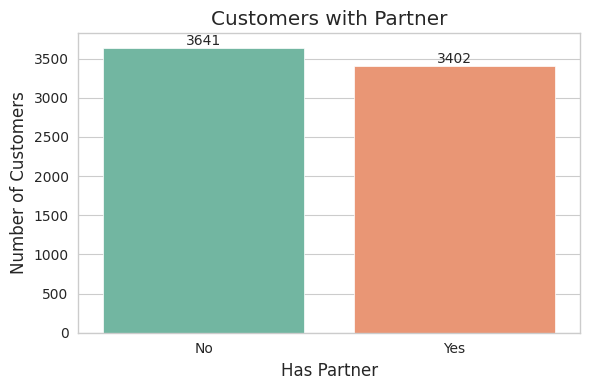

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Partner",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customers with Partner")
plt.xlabel("Has Partner")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

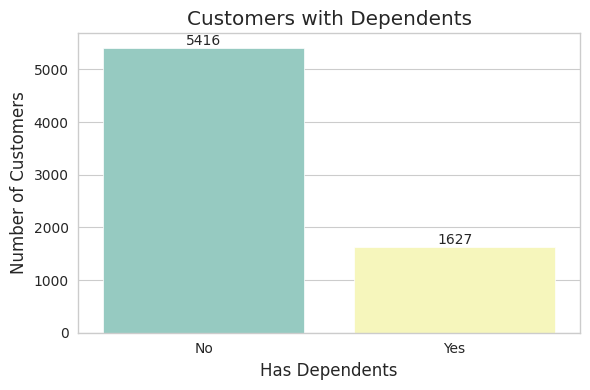

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Dependents",
    palette="Set3"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customers with Dependents")
plt.xlabel("Has Dependents")
plt.ylabel("Number of Customers")

plt.tight_layout()


plt.show()

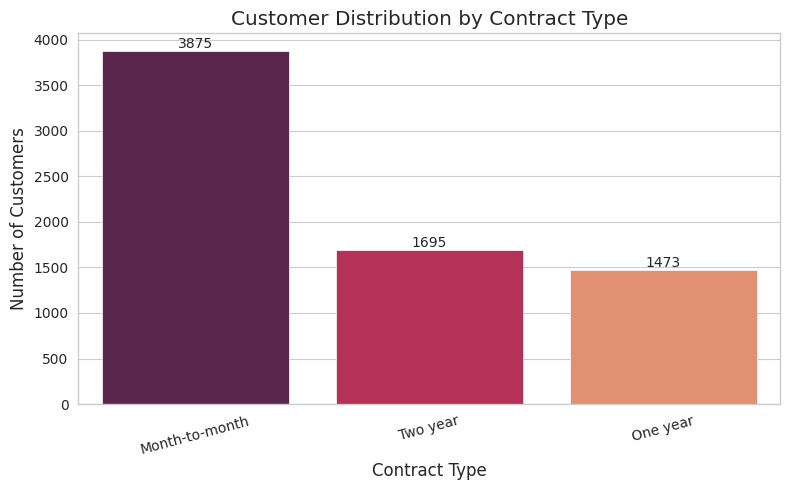

In [ ]:
# Customer Behaviour Analysis

plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=df,
    x="Contract",
    palette="rocket"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.tight_layout()


plt.show()

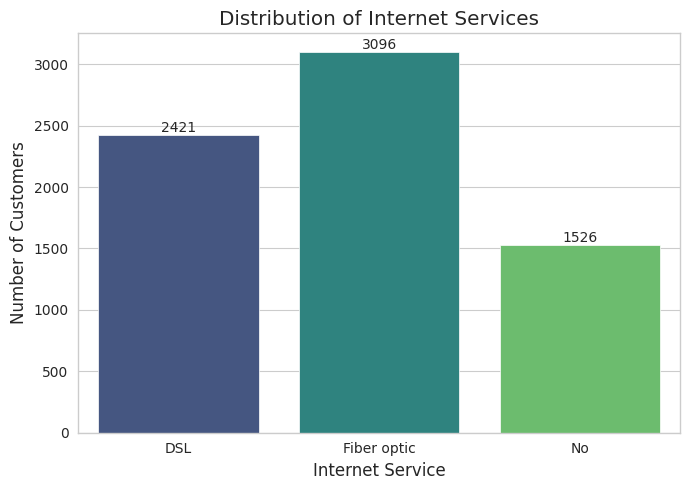

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Internet Service",
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Internet Services")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.tight_layout()


plt.show()

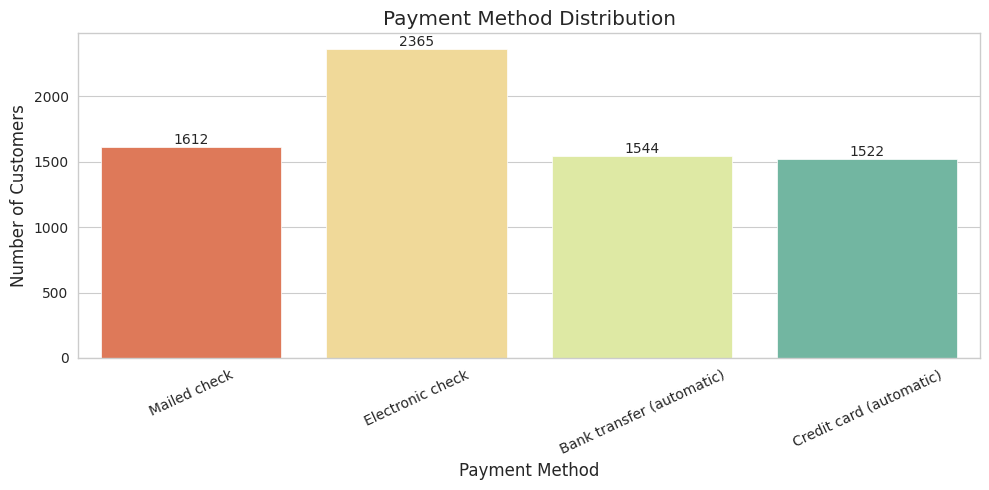

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x="Payment Method",
    palette="Spectral"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=25)

plt.tight_layout()


plt.show()

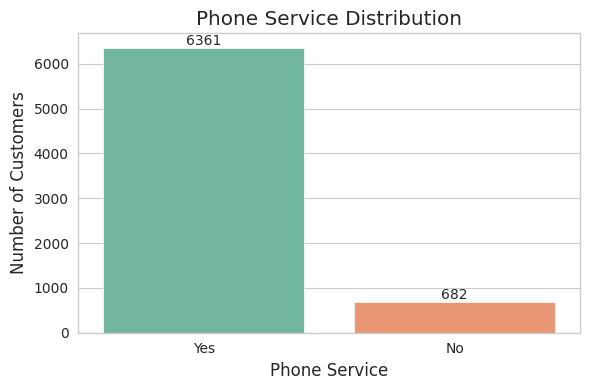

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Phone Service",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Phone Service Distribution")
plt.xlabel("Phone Service")
plt.ylabel("Number of Customers")

plt.tight_layout()


plt.show()

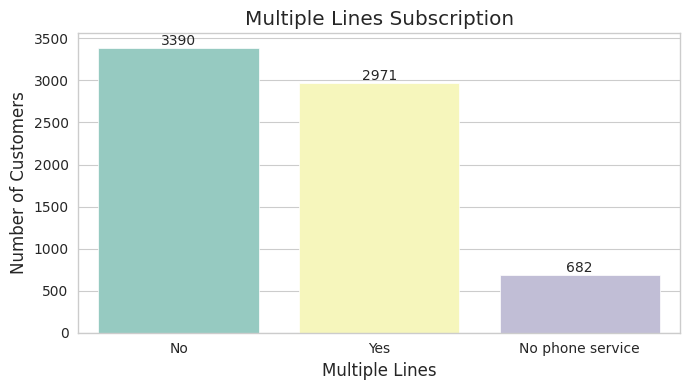

In [ ]:
plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=df,
    x="Multiple Lines",
    palette="Set3"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Multiple Lines Subscription")
plt.xlabel("Multiple Lines")
plt.ylabel("Number of Customers")

plt.tight_layout()


plt.show()

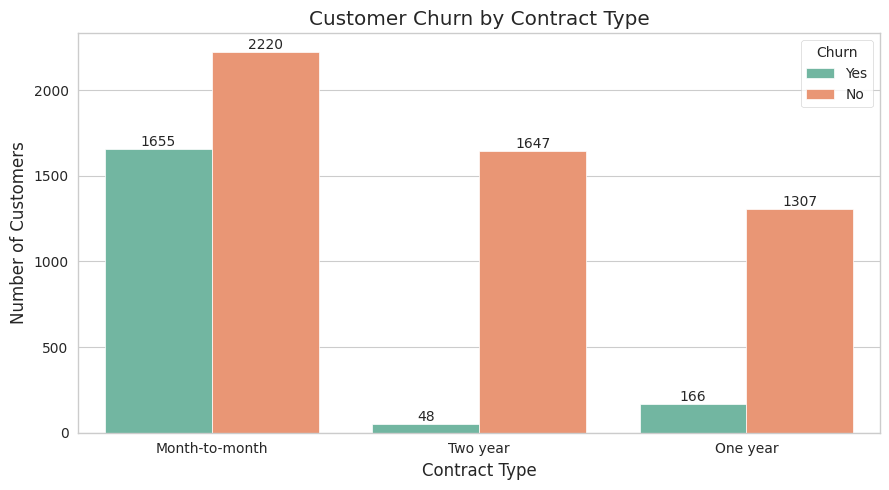

In [ ]:
# Contract Type vs Customer Churn

plt.figure(figsize=(9,5))

ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Label",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()


plt.show()

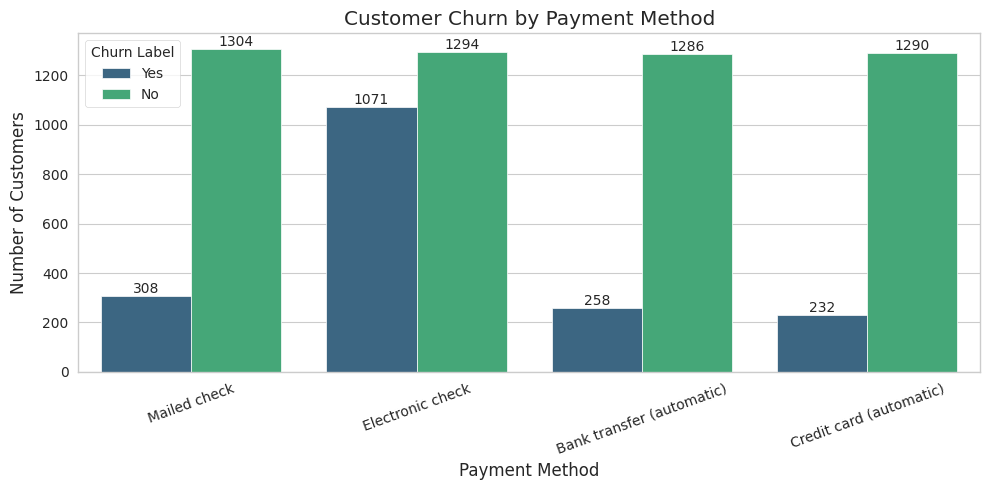

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Label",
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=20)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.tight_layout()


plt.show()

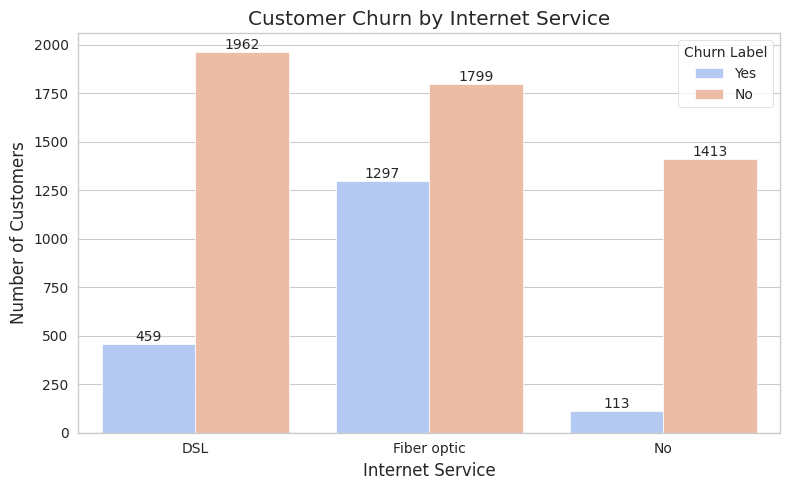

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Label",
    palette="coolwarm"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.tight_layout()


plt.show()

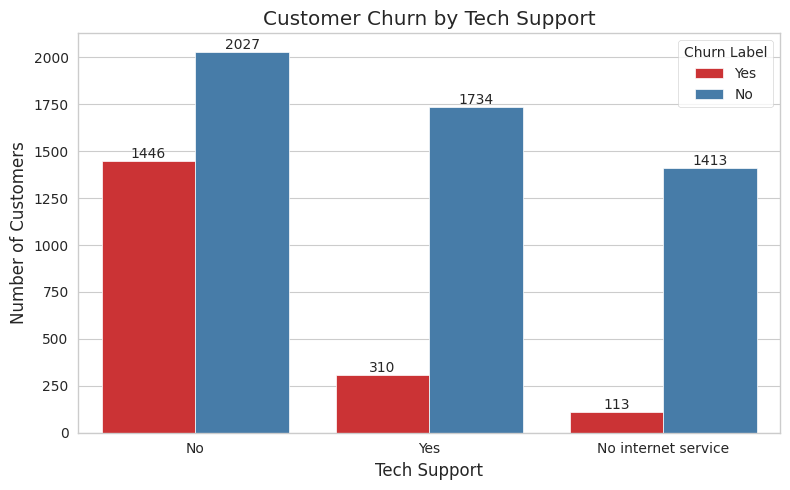

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Tech Support",
    hue="Churn Label",
    palette="Set1"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.tight_layout()


plt.show()

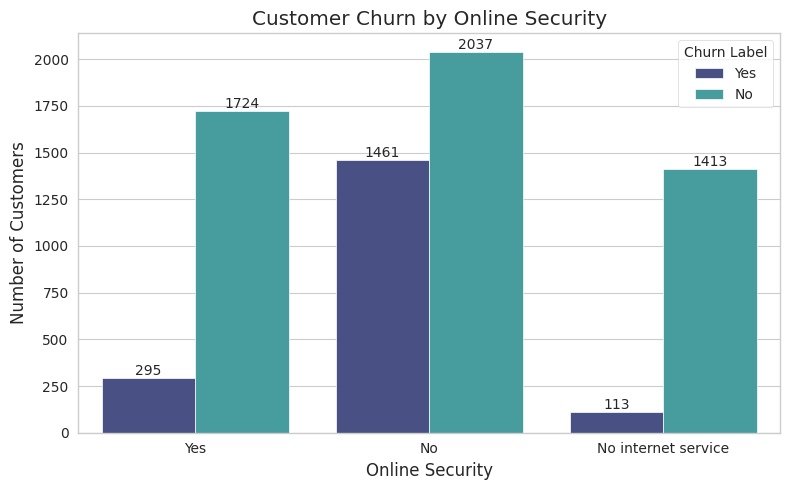

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Online Security",
    hue="Churn Label",
    palette="mako"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")

plt.tight_layout()


plt.show()

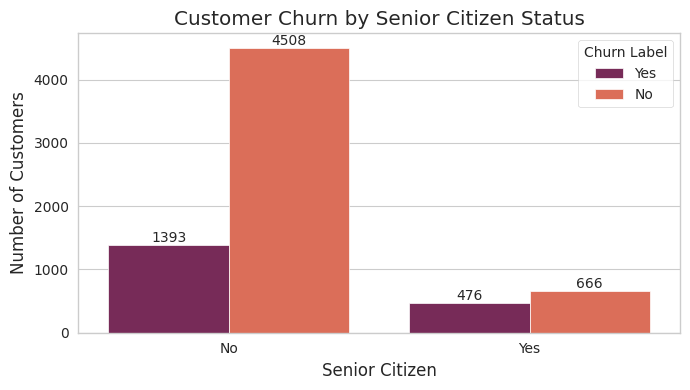

In [ ]:
plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=df,
    x="Senior Citizen",
    hue="Churn Label",
    palette="rocket"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.tight_layout()


plt.show()

In [ ]:
contract_churn = (
    df.groupby("Contract")["Churn Value"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

print(contract_churn)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn Value, dtype: float64


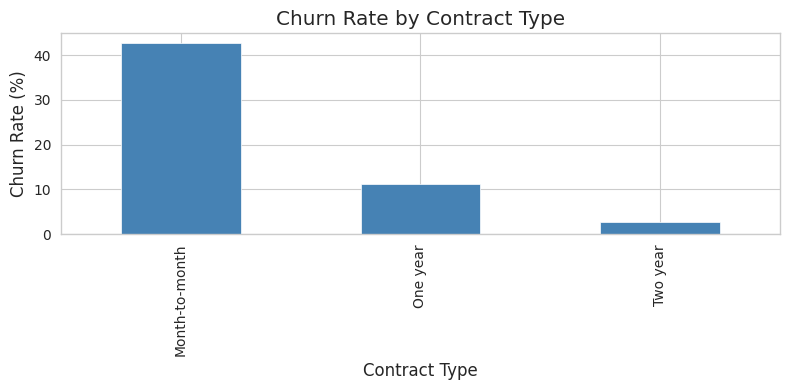

In [ ]:
plt.figure(figsize=(8,4))

contract_churn.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()


plt.show()

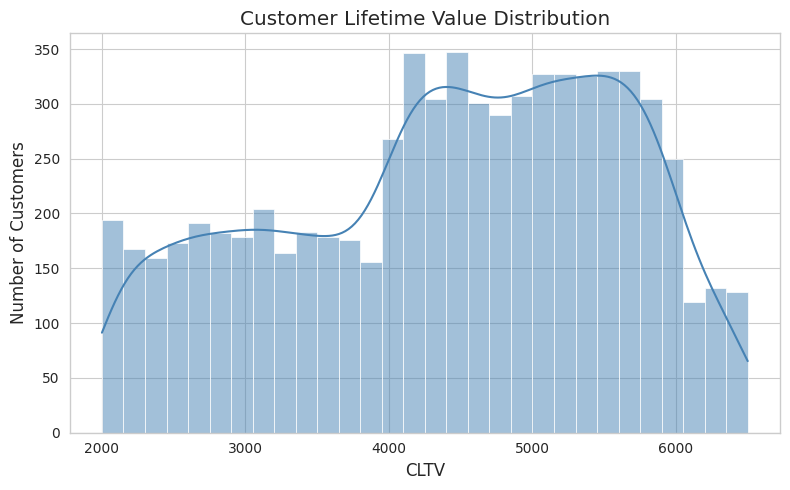

In [ ]:
# Customer Lifetime Value (CLTV)

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="CLTV",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLTV")
plt.ylabel("Number of Customers")

plt.tight_layout()


plt.show()

In [ ]:
top_customers = (
    df.sort_values("CLTV", ascending=False)
      [["CustomerID","CLTV","Monthly Charges","Tenure Months"]]
      .head(10)
)

top_customers

,CustomerID,CLTV,Monthly Charges,Tenure Months
3482,7622-FWGEW,6500,85.65,56
6202,0383-CLDDA,6499,85.35,69
2550,6024-RUGGH,6499,25.20,72
3600,2683-JXWQQ,6495,33.60,61
6839,4114-QMKVN,6494,68.75,56
3446,8894-JVDCV,6494,115.05,62
6411,1658-XUHBX,6492,88.75,59
4023,2181-TIDSV,6492,19.95,68
3842,4531-AUZNK,6492,95.15,51
5964,0675-NCDYU,6491,116.40,72


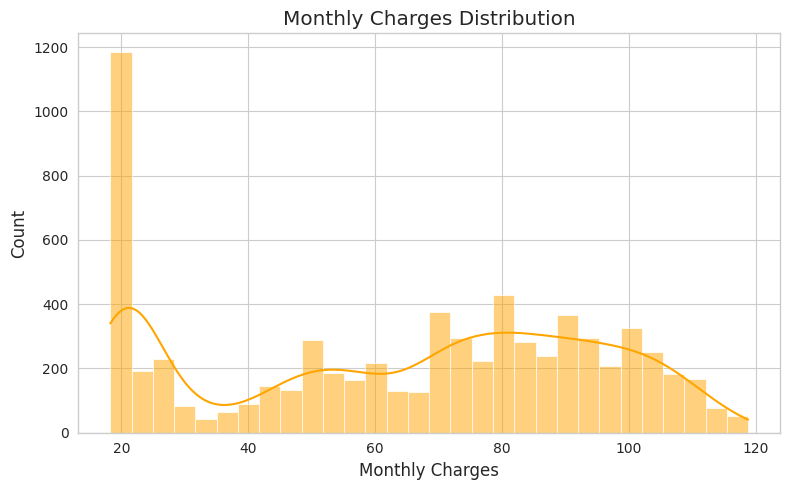

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Monthly Charges",
    bins=30,
    color="orange",
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.tight_layout()



plt.show()

In [ ]:
revenue_at_risk = df[df["Churn Label"]=="Yes"]["CLTV"].sum()

print(f"Total Revenue at Risk : ₹{revenue_at_risk:,.0f}")

Total Revenue at Risk : ₹7,755,256


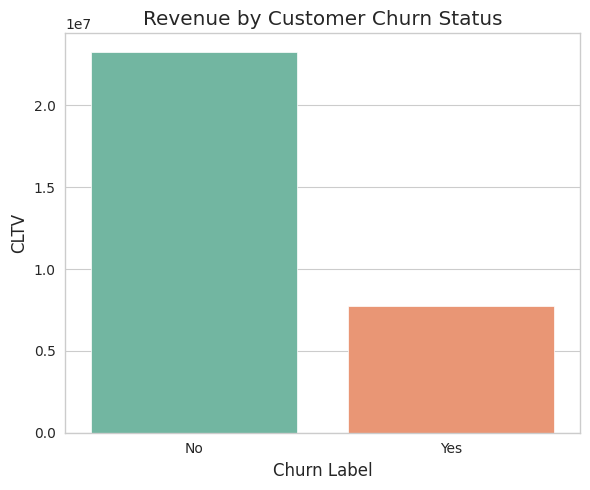

In [ ]:
revenue = (
    df.groupby("Churn Label")["CLTV"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(6,5))

sns.barplot(
    data=revenue,
    x="Churn Label",
    y="CLTV",
    palette="Set2"
)

plt.title("Revenue by Customer Churn Status")

plt.tight_layout()



plt.show()

In [ ]:
high_value = df[
    (df["CLTV"] > df["CLTV"].quantile(0.75)) &
    (df["Churn Score"] > 75)
]

high_value.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
5,4190-MFLUW,1,United States,California,Los Angeles,90020,"34.066367, -118.309868",34.066367,-118.309868,Female,...,Month-to-month,No,Credit card (automatic),55.20,528.35,Yes,1,78,5925,Competitor offered higher download speeds
6,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,Male,...,Month-to-month,Yes,Electronic check,39.65,39.65,Yes,1,100,5433,Competitor offered more data
8,6467-CHFZW,1,United States,California,Los Angeles,90028,"34.099869, -118.326843",34.099869,-118.326843,Male,...,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,1,77,5789,Competitor had better devices
14,7760-OYPDY,1,United States,California,Los Angeles,90056,"33.987945, -118.370442",33.987945,-118.370442,Female,...,Month-to-month,Yes,Electronic check,80.65,144.15,Yes,1,90,5586,Competitor offered more data
18,5698-BQJOH,1,United States,California,Beverly Hills,90211,"34.063947, -118.383001",34.063947,-118.383001,Female,...,Month-to-month,No,Electronic check,94.40,857.25,Yes,1,96,5571,Price too high


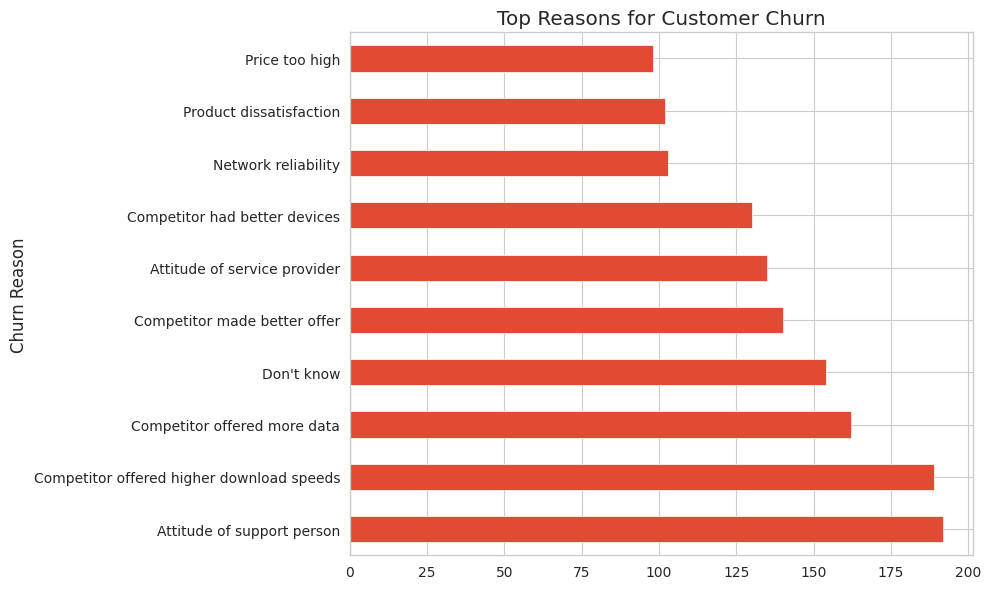

In [ ]:
plt.figure(figsize=(10,6))

(
    df[df["Churn Label"]=="Yes"]
      ["Churn Reason"]
      .value_counts()
      .head(10)
      .plot(kind="barh")
)

plt.title("Top Reasons for Customer Churn")

plt.tight_layout()


plt.show()

In [ ]:
# Create a copy of the cleaned dataset

model_df = df.copy()

print("Shape :", model_df.shape)

model_df.head()

Shape : (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
model_df.shape

(7043, 33)

In [ ]:
columns_to_drop = [

    
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "CLTV",
    "Churn Value",
    "Churn Score",
    "Churn Reason"

]

In [ ]:
model_df.drop(columns=columns_to_drop, inplace=True)

print(model_df.shape)

model_df.head()

(7043, 20)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes


In [ ]:
model_df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label'],
      dtype='object')

In [ ]:
# Double-checking the remaining columns

print("Remaining Features :", model_df.shape[1]-1)
print("Target Column :", "Churn Label")

Remaining Features : 19
Target Column : Churn Label


In [ ]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [ ]:
#Separate Numerical & Categorical Columns

numerical_columns = model_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


#text values must be encoded before training.

categorical_columns = model_df.select_dtypes(
    include=["object"]
).columns.tolist()


print("Numerical Features")
print(numerical_columns)

print()

print("Categorical Features")
print(categorical_columns)

Numerical Features
['Tenure Months', 'Monthly Charges']

Categorical Features
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Label']


In [ ]:
categorical_columns.remove("Churn Label")

In [ ]:
print(categorical_columns)

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges']


In [ ]:
print(model_df["Total Charges"].dtype)

object


In [ ]:
#Some values are stored as text instead of numbers. We convert them into numeric values.

model_df["Total Charges"] = pd.to_numeric(
    model_df["Total Charges"],
    errors="coerce"
)

In [ ]:
print(model_df["Total Charges"].dtype)

float64


In [ ]:
model_df["Total Charges"].isnull().sum()

np.int64(11)

In [ ]:
model_df["Total Charges"].fillna(
    model_df["Total Charges"].median(),
    inplace=True
)

In [ ]:
numerical_columns = model_df.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_columns = model_df.select_dtypes(
    include=["object"]
).columns.tolist()

categorical_columns.remove("Churn Label")

In [ ]:
print(numerical_columns)

print()

print(categorical_columns)

['Tenure Months', 'Monthly Charges', 'Total Charges']

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [ ]:
model_df.info()
print(numerical_columns)
print(categorical_columns)
model_df["Total Charges"].dtype


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

dtype('float64')

In [ ]:
print(model_df["Total Charges"].isnull().sum())

0


In [ ]:
# Save the cleaned dataset for future notebooks

(PROJECT_ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)

model_df.to_csv(
    PROJECT_ROOT / "data" / "processed" / "cleaned_customer_data.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/AI Relationship Manager/data/processed'

In [ ]:
# Save the cleaned dataset for future notebooks


Cleaned dataset saved successfully!
